The provided scrip will plot the calculated statistical parameters of the features on the GRIDMAP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import os


<>:64: SyntaxWarning: invalid escape sequence '\G'
<>:64: SyntaxWarning: invalid escape sequence '\G'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:64: SyntaxWarning: invalid escape sequence '\G'
  df_corr = pd.read_csv('C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\GRID-FB-UP_ICE\GRID-FB-UP_ICE-distribution.csv')  # Replace with your actual DataFrame loading code
C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


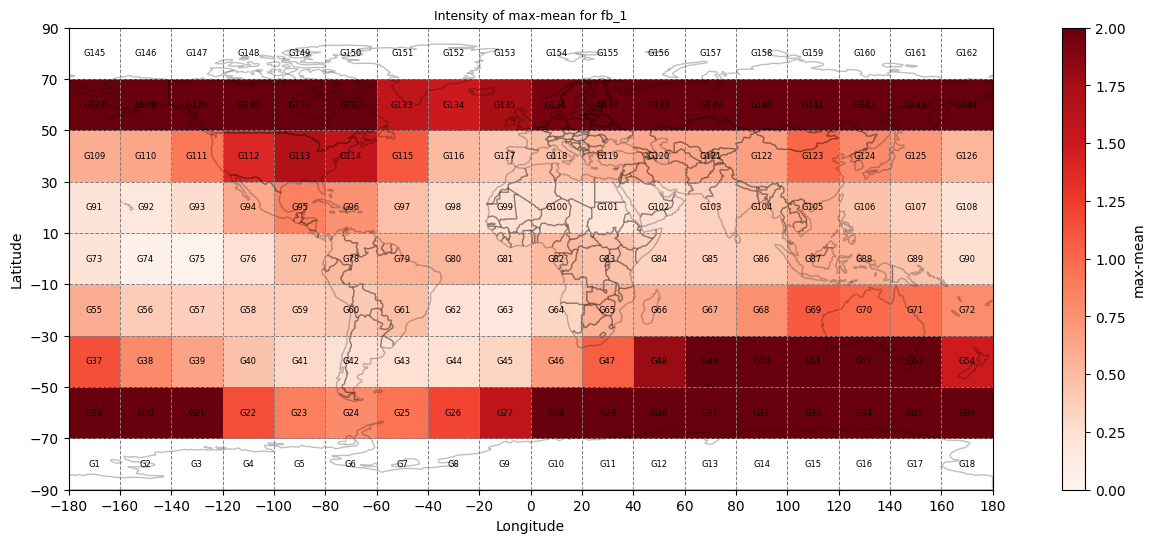

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


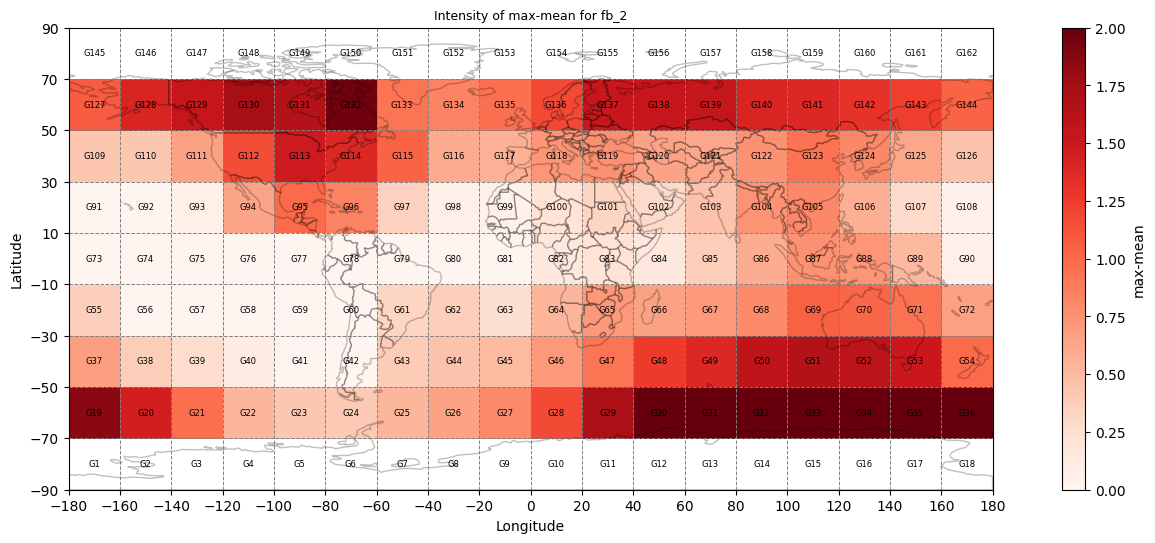

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


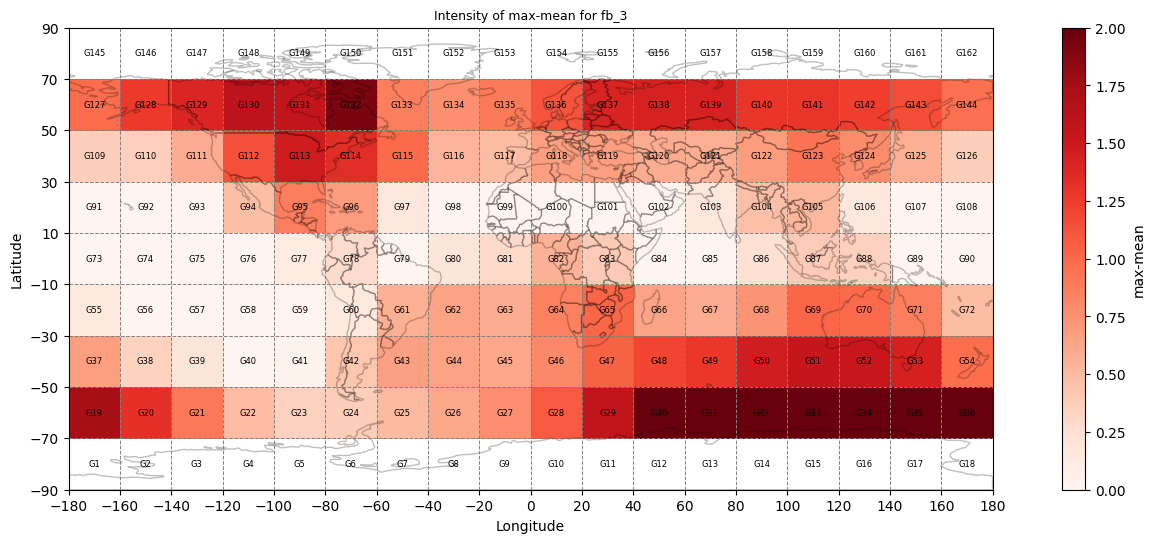

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


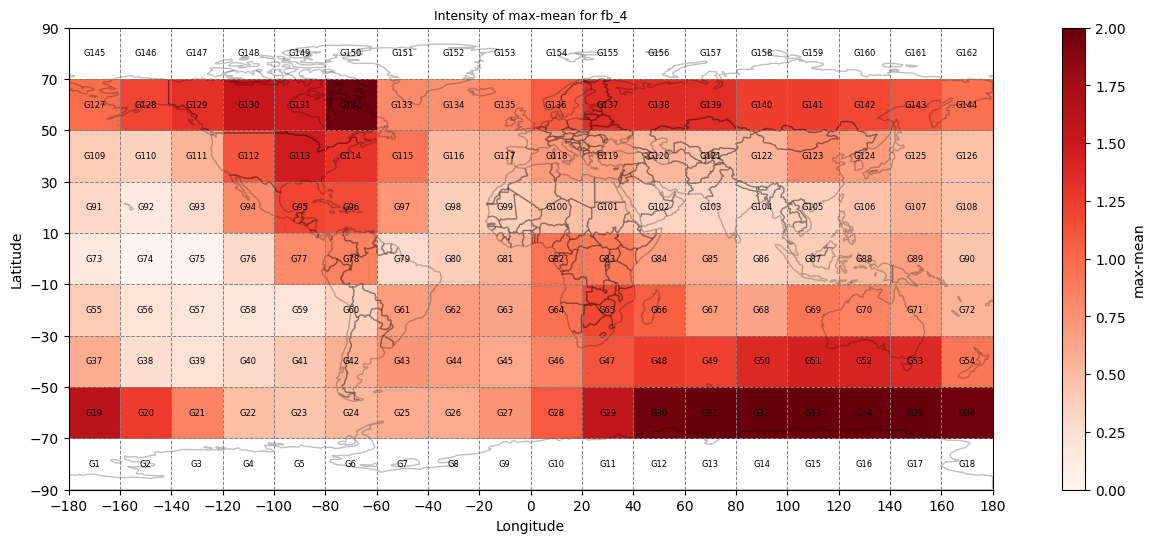

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


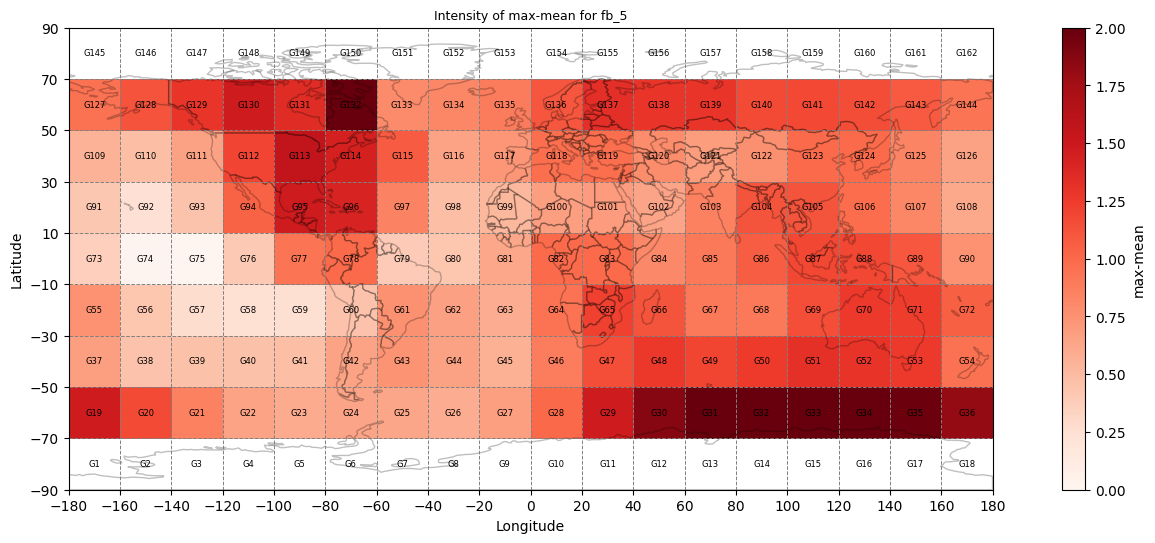

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


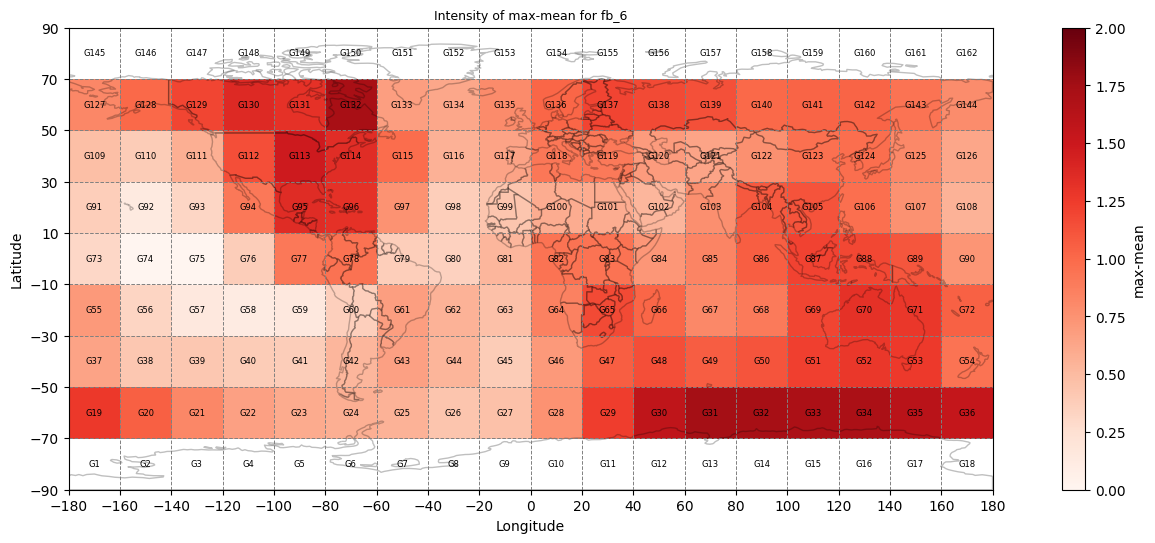

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


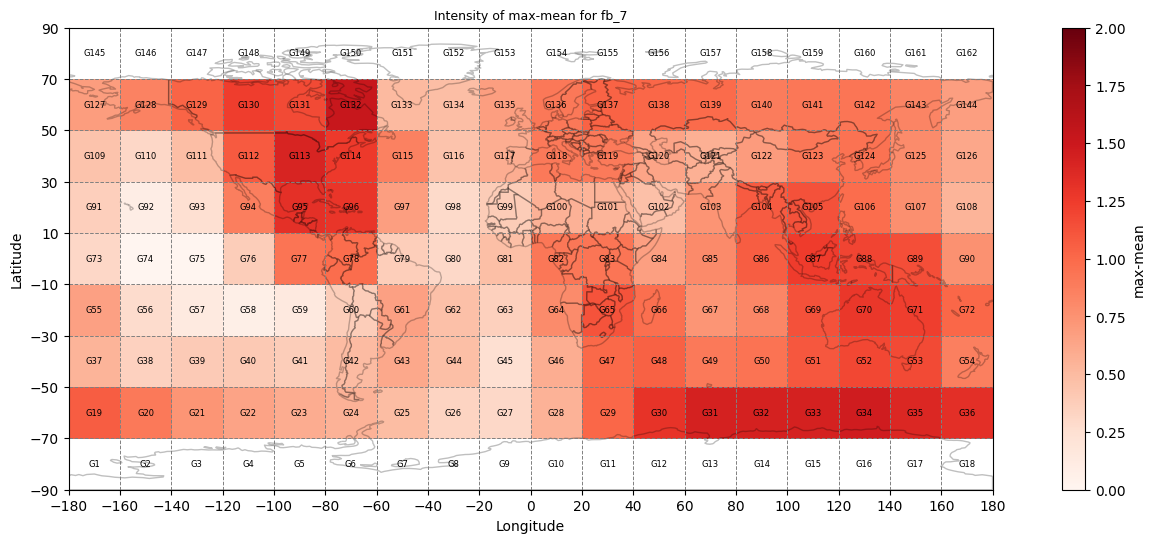

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


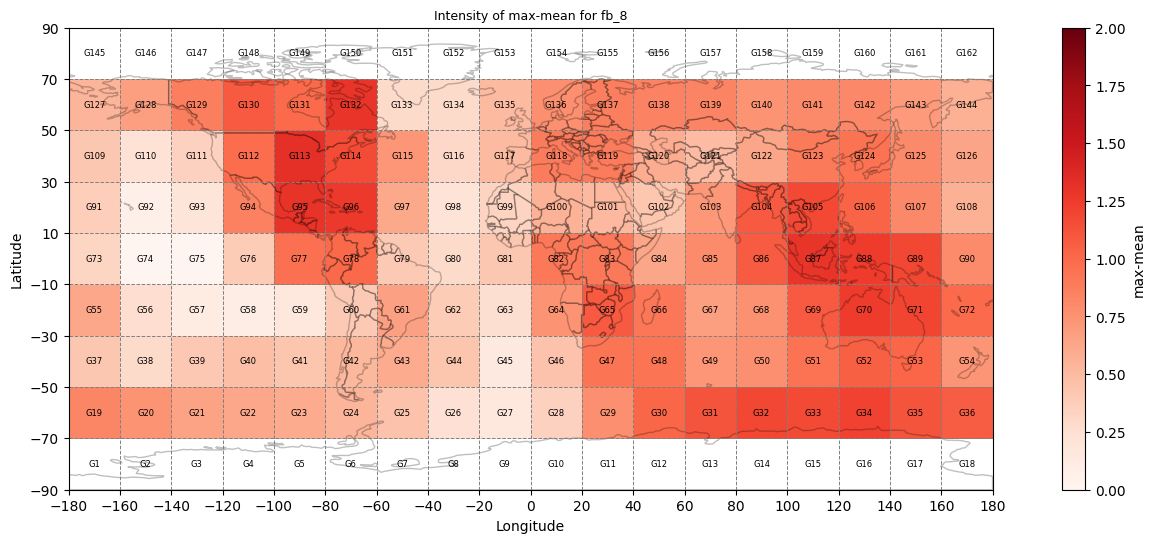

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


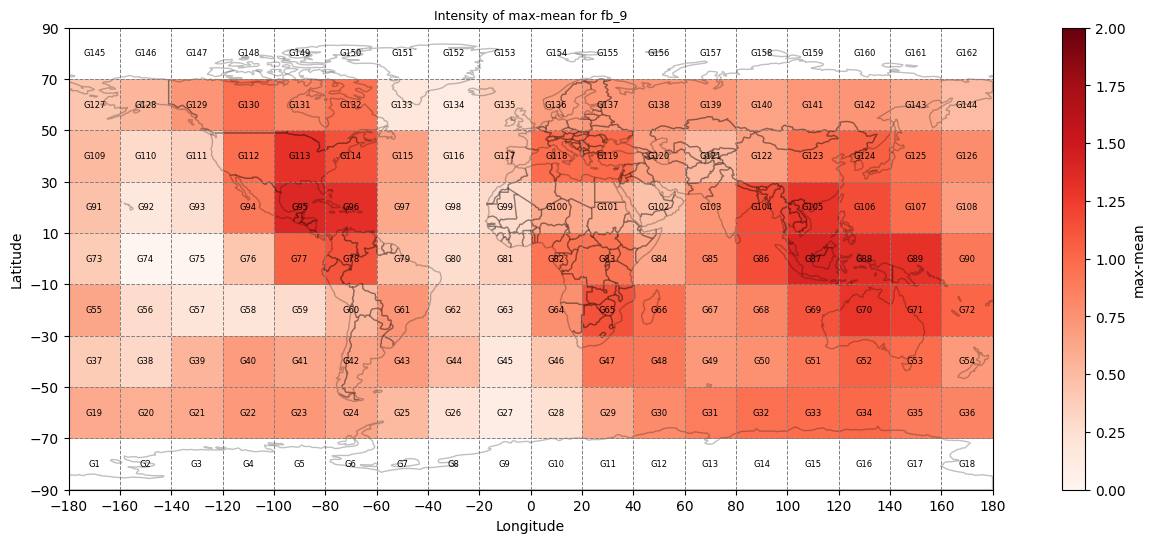

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


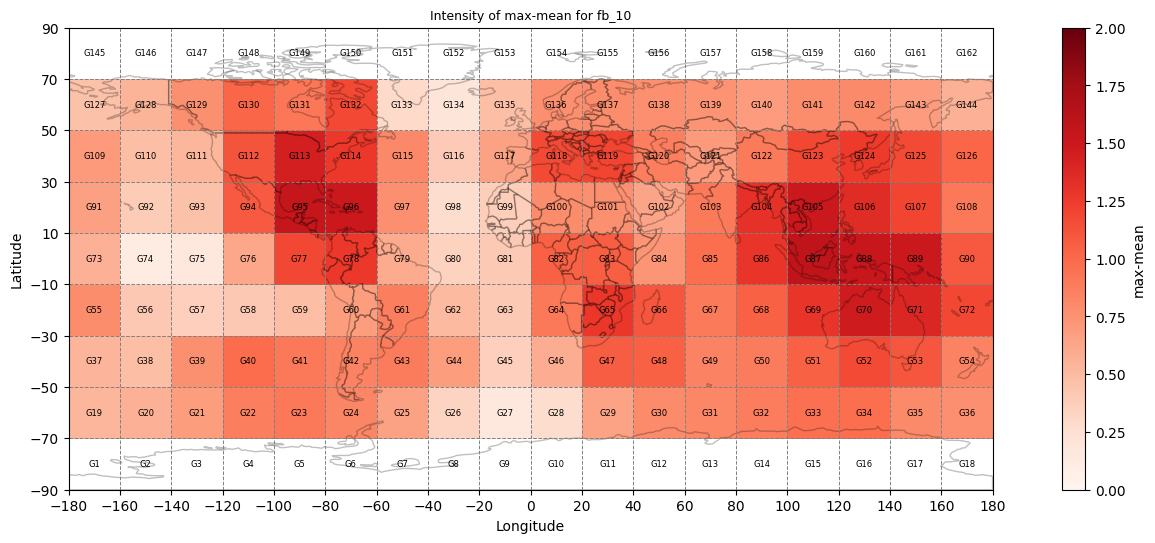

C:\Users\mbabu\AppData\Local\Temp\ipykernel_125772\2714933593.py:20: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


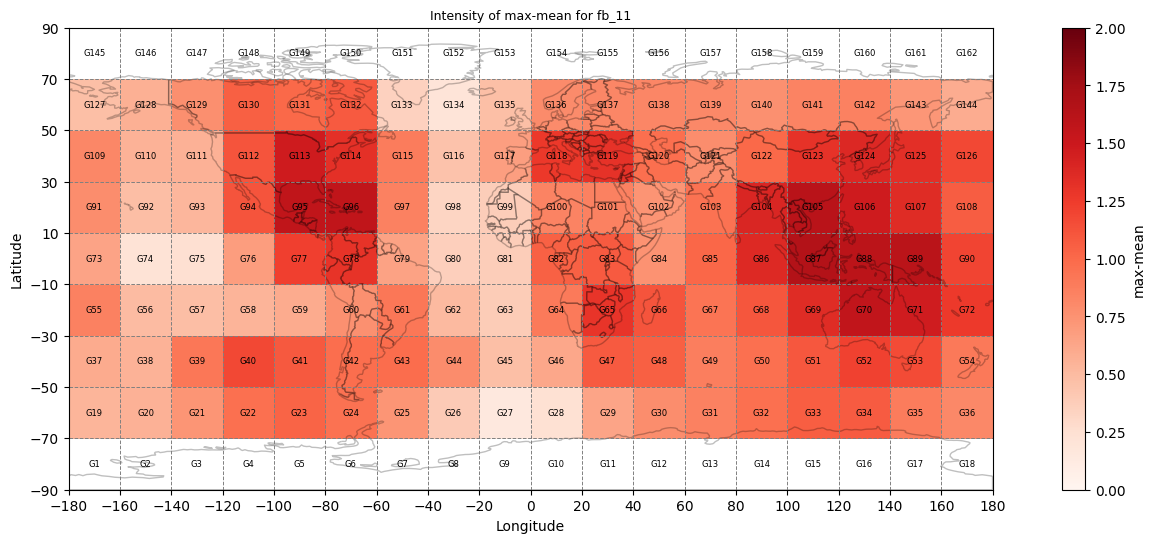

In [5]:


def create_grid(width, depth):
    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180, 180
    
    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)
    
    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}'

    return grid


def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column, Band_Key):
    fig, ax = plt.subplots(figsize=(18, 6))
    cmap = 'Reds'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', cmap=cmap, alpha=0.25, zorder=2)
    
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)
    for lon in np.arange(0, 361, width):
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)
    
    intensities = np.zeros(grid.shape)
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            
            if specific_key in all_data.index:
                intensity = all_data.at[specific_key, intensity_column]  # Use .at[] for a single value
                intensities[lat_idx, lon_idx] = intensity
            else:
                intensities[lat_idx, lon_idx] = np.nan  # Assign NaN if specific_key not found

    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower')
    im.set_clim(vmin=0, vmax=2)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(intensity_column)
    
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize=6)
    
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))
    
    ax.set_title(f'Intensity of {intensity_column} for {Band_Key}', fontsize=9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    folder_path = r"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE\\Params_Heatmap"
    os.makedirs(folder_path, exist_ok=True)
    
    plt.savefig(os.path.join(folder_path, f'{Band_Key}_{intensity_column}.png'),dpi =300)
    plt.show()

# Assuming your DataFrame is named df_corr
df_corr = pd.read_csv('C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\GRID-FB-UP_ICE\GRID-FB-UP_ICE-distribution.csv')  # Replace with your actual DataFrame loading code

skip_ranges = [(1, 18), (145, 162)]
fdf = df_corr[~df_corr['specific_key'].str[1:].astype(int).between(1, 18) & ~df_corr['specific_key'].str[1:].astype(int).between(145, 162)]
fdf.reset_index(drop=True, inplace=True)

unique_band_keys = fdf['band_key'].unique()
grid = create_grid(20, 20)

for Band_Key in unique_band_keys:
    new_df = fdf[fdf['band_key'] == Band_Key]
    new_df = new_df[['specific_key', 'band_key',
                     'q1-mean', 'q2-mean', 'q3-mean', 'max-mean',
                     'q1-median', 'q2-median', 'q3-median', 'max-median',
                     'q1-rmsq', 'q2-rmsq', 'q3-rmsq', 'max-rmsq',
                     'q1-std', 'q2-std', 'q3-std', 'max-std']].set_index('specific_key')
    # print(new_df)

    plot_grid_with_intensity(grid, 20, 20, new_df, 'max-mean', Band_Key)
